In [1]:
import pandas as pd

df = pd.read_csv("AGB_EO_EMIT.csv")

print(df.shape)
print(df.columns)
df.head()

(3880, 314)
Index(['dataset', 'plot_id', 'start_date', 'end_date', 'capture_start',
       'capture_end', 'EMIT_selected_date', 'EMIT_granule', 'latitude',
       'longitude',
       ...
       'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424',
       'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796'],
      dtype='object', length=314)


,dataset,plot_id,start_date,end_date,capture_start,capture_end,EMIT_selected_date,EMIT_granule,latitude,longitude,...,EMIT_R1342,EMIT_R1350,EMIT_R1357,EMIT_R1417,EMIT_R1424,EMIT_R1432,EMIT_R1774,EMIT_R1781,EMIT_R1789,EMIT_R1796
0,Belige,Big Creek_1,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510383,-88.424776,...,0.352271,0.455214,0.894292,0.513815,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285
1,Belige,Big Creek_1,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510383,-88.424776,...,0.352271,0.455214,0.894292,0.513815,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285
2,Belige,Big Creek_1,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510383,-88.424776,...,0.352271,0.455214,0.894292,0.513815,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285
3,Belige,Big Creek_1,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510383,-88.424776,...,0.352271,0.455214,0.894292,0.513815,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285
4,Belige,Big Creek_1,2021-01-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2024-07-20 20:44:04+00:00,EMIT_L2A_RFL_001_20240720T204404_2420214_006.nc,16.510383,-88.424776,...,0.352271,0.455214,0.894292,0.513815,0.362984,0.288413,0.257263,0.266405,0.274731,0.291285


In [2]:
print(df["plot_id"].value_counts().head())

plot_id
Channel Caye_4      120
Frenchman Caye_6    118
Frenchman Caye_3    117
Payne's Creek_2     116
Frenchman Caye_2    105
Name: count, dtype: int64


In [3]:
# Mean for features
df_features = df.groupby("plot_id").mean(numeric_only=True)

# SUM for AGB (this is the fix)
df_agb = df.groupby("plot_id")["plant_AGB_kg"].sum()

# Combine
df_plot = df_features.copy()
df_plot["plant_AGB_kg"] = df_agb

df_plot = df_plot.reset_index()

print(df_plot.shape)

(59, 306)


In [4]:
features = [
    "NDVI", "EVI", "NDRE1", "NDRE2", "NDRE3",
    "MSI", "NBR",
    "latitude", "longitude"
]

# Check they exist
for f in features:
    if f not in df_plot.columns:
        print("Missing:", f)

In [5]:
import numpy as np

df_plot["AGB_log"] = np.log1p(df_plot["plant_AGB_kg"])

print(df_plot[["plot_id", "plant_AGB_kg", "AGB_log"]].head())

       plot_id  plant_AGB_kg   AGB_log
0  Big Creek_1      0.129004  0.121335
1  Big Creek_2     91.275545  4.524779
2  Big Creek_3     75.398412  4.335962
3  Big Creek_4      0.231102  0.207910
4  Big Creek_5     16.866336  2.882918


In [6]:
X = df_plot[features].values
y = df_plot["AGB_log"].values

print(X.shape)
print(y.shape)

(59, 9)
(59,)


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Features ---
features = [
    "NDVI", "EVI", "NDRE1", "NDRE2", "NDRE3",
    "MSI", "NBR",
    "latitude", "longitude"
]

# --- Prepare data ---
X = df_plot[features].values
y = df_plot["AGB_log"].values

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# --- Scale ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Model ---
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=2
)

rf.fit(X_train_scaled, y_train)

# --- Predict ---
y_pred_log = rf.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("EO + EMIT Model Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

EO + EMIT Model Results
RMSE: 51.19394966188891
MAE: 39.91494586674889
R2: 0.631048062439878


The EO + EMIT model using engineered spectral indices achieved strong performance (R² ≈ 0.63), closely approaching the EMIT PCA neural network (R² ≈ 0.685). While slightly lower in predictive accuracy, this model benefits from improved interpretability and stability, as it relies on physically meaningful indices such as NDVI, EVI, and NDRE rather than abstract principal components. This suggests that engineered spectral features can capture most of the relevant signal for biomass prediction while offering a more transparent modeling approach.

     feature  importance
5        MSI    0.610972
6        NBR    0.252319
7   latitude    0.054843
8  longitude    0.032321
4      NDRE3    0.019852
1        EVI    0.009918
2      NDRE1    0.007179
3      NDRE2    0.006941
0       NDVI    0.005655


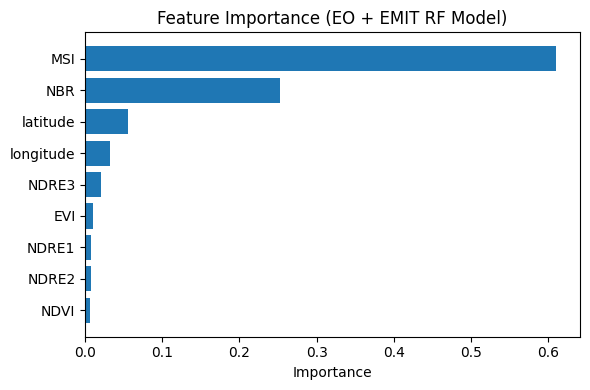

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Get importance
importances = rf.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_df)

# Plot
plt.figure(figsize=(6,4))
plt.barh(feat_df["feature"], feat_df["importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance (EO + EMIT RF Model)")

plt.tight_layout()

Feature importance analysis reveals that the model relies heavily on moisture and stress-related indices, with MSI and NBR accounting for over 85% of total importance. In contrast, traditional vegetation indices such as NDVI and EVI contribute very little to the model’s predictions. This suggests that, in this dataset, aboveground biomass is more strongly associated with vegetation moisture conditions and stress signals than with simple greenness measures. Additionally, geographic features such as latitude and longitude provide some predictive value, indicating regional variability in biomass patterns.

Direct diffusion on EO + EMIT dataset

In [10]:
y_mean = y_train.mean()
y_std  = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled  = (y_test - y_mean) / y_std

print("Mean:", y_train_scaled.mean())
print("Std:", y_train_scaled.std())

Mean: 2.391703856240364e-16
Std: 1.0


In [11]:
T = 30

betas = np.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

In [12]:
X_train_c = X_train_scaled

X_expanded = []
y_t_expanded = []
t_expanded = []
noise_expanded = []

for i in range(len(X_train_c)):
    for t in range(T):
        noise = np.random.normal(0, 1)

        y0 = y_train_scaled[i]

        y_t = (
            np.sqrt(alpha_bars[t]) * y0 +
            np.sqrt(1 - alpha_bars[t]) * noise
        )

        X_expanded.append(X_train_c[i])
        y_t_expanded.append(y_t)
        t_expanded.append(t / T)
        noise_expanded.append(noise)

X_expanded = np.array(X_expanded)
y_t_expanded = np.array(y_t_expanded).reshape(-1, 1)
t_expanded = np.array(t_expanded).reshape(-1, 1)
noise_expanded = np.array(noise_expanded).reshape(-1, 1)

print("Expanded:", X_expanded.shape)

Expanded: (1410, 9)


In [13]:
from tensorflow.keras import layers, Model

x_input = layers.Input(shape=(X_expanded.shape[1],))
y_input = layers.Input(shape=(1,))
t_input = layers.Input(shape=(1,))

combined = layers.Concatenate()([x_input, y_input, t_input])

h = layers.Dense(64, activation="relu")(combined)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

output = layers.Dense(1)(h)

diff_model_eo = Model(inputs=[x_input, y_input, t_input], outputs=output)

diff_model_eo.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [15]:
import tensorflow as tf

history = diff_model_eo.fit(
    [X_expanded, y_t_expanded, t_expanded],
    noise_expanded,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.8836 - mae: 0.7414 - val_loss: 0.6121 - val_mae: 0.6387
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7276 - mae: 0.6644 - val_loss: 0.5436 - val_mae: 0.5896
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.6235 - mae: 0.6118 - val_loss: 0.4618 - val_mae: 0.5192
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.5500 - mae: 0.5663 - val_loss: 0.3743 - val_mae: 0.4539
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5147 - mae: 0.5453 - val_loss: 0.3993 - val_mae: 0.4847
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5054 - mae: 0.5306 - val_loss: 0.4432 - val_mae: 0.5108
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4583 - mae: 0.4996 - val_loss: 0.4486 - val_mae: 0.5160
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4608 - mae: 0.5048 - val_loss: 0.4302 - val_mae: 0.4826
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss

In [16]:
def sample_direct_diffusion(model, X_condition, n_samples=100):
    all_samples = []

    for _ in range(n_samples):
        y_sample = np.random.normal(size=(X_condition.shape[0], 1))

        for t in reversed(range(T)):
            t_scaled = np.full((X_condition.shape[0], 1), t / T)

            pred_noise = model.predict(
                [X_condition, y_sample, t_scaled],
                verbose=0
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            y_sample = (1 / np.sqrt(alpha_t)) * (
                y_sample - ((1 - alpha_t) / np.sqrt(1 - alpha_bar_t)) * pred_noise
            )

            if t > 0:
                z = np.random.normal(size=y_sample.shape)
                y_sample = y_sample + np.sqrt(beta_t) * z

        all_samples.append(y_sample.ravel())

    return np.array(all_samples)

In [17]:
samples_scaled = sample_direct_diffusion(
    diff_model_eo,
    X_test_scaled,
    n_samples=100
)

print("Samples shape:", samples_scaled.shape)

Samples shape: (100, 12)


In [18]:
samples_log = samples_scaled * y_std + y_mean
samples_agb = np.expm1(samples_log)
diff_pred = samples_agb.mean(axis=0)
diff_lower = np.percentile(samples_agb, 5, axis=0)
diff_upper = np.percentile(samples_agb, 95, axis=0)
y_true = np.expm1(y_test)

rmse_diff = np.sqrt(mean_squared_error(y_true, diff_pred))
mae_diff = mean_absolute_error(y_true, diff_pred)
r2_diff = r2_score(y_true, diff_pred)

print("Direct EO + EMIT Diffusion Results")
print("RMSE:", rmse_diff)
print("MAE:", mae_diff)
print("R2:", r2_diff)

print("\nUncertainty interval examples:")
for i in range(5):
    print(
        "Actual:", round(y_true[i], 2),
        "| Pred mean:", round(diff_pred[i], 2),
        "| 5-95% interval:",
        round(diff_lower[i], 2),
        "-",
        round(diff_upper[i], 2)
    )

Direct EO + EMIT Diffusion Results
RMSE: 74.41186115694792
MAE: 53.13932977708226
R2: 0.2204986792752578

Uncertainty interval examples:
Actual: 193.29 | Pred mean: 252.18 | 5-95% interval: 104.37 - 487.95
Actual: 209.35 | Pred mean: 173.03 | 5-95% interval: 37.02 - 385.89
Actual: 22.31 | Pred mean: 54.82 | 5-95% interval: 4.72 - 252.29
Actual: 234.88 | Pred mean: 150.7 | 5-95% interval: 45.65 - 360.34
Actual: 3.04 | Pred mean: 5.14 | 5-95% interval: 2.31 - 12.26


Applying diffusion to the EO + EMIT engineered feature dataset resulted in moderate predictive performance (R² ≈ 0.22), which is lower than the Random Forest model (R² ≈ 0.63). However, unlike previous experiments with EMIT data, the diffusion model produced stable predictions and meaningful uncertainty intervals. The results suggest that diffusion is better suited for uncertainty estimation rather than improving prediction accuracy in this setting. The generated prediction intervals adapt to the difficulty of each sample, providing wider ranges for more uncertain predictions and narrower ranges for easier cases.

In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


T = 10
betas = np.linspace(0.00001, 0.005, T)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

y_mean = y_train.mean()
y_std = y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std
X_train_c = X_train_scaled

X_expanded = []
y_t_expanded = []
t_expanded = []
noise_expanded = []

for i in range(len(X_train_c)):
    for t in range(T):
        noise = np.random.normal(0, 1)
        y0 = y_train_scaled[i]

        y_t = (
            np.sqrt(alpha_bars[t]) * y0
            + np.sqrt(1 - alpha_bars[t]) * noise
        )

        X_expanded.append(X_train_c[i])
        y_t_expanded.append(y_t)
        t_expanded.append(t / T)
        noise_expanded.append(noise)

X_expanded = np.array(X_expanded)
y_t_expanded = np.array(y_t_expanded).reshape(-1, 1)
t_expanded = np.array(t_expanded).reshape(-1, 1)
noise_expanded = np.array(noise_expanded).reshape(-1, 1)

print("Expanded:", X_expanded.shape)


x_input = layers.Input(shape=(X_expanded.shape[1],))
y_input = layers.Input(shape=(1,))
t_input = layers.Input(shape=(1,))

combined = layers.Concatenate()([x_input, y_input, t_input])

h = layers.Dense(64, activation="relu")(combined)
h = layers.Dropout(0.2)(h)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dropout(0.2)(h)
h = layers.Dense(32, activation="relu")(h)

output = layers.Dense(1)(h)

diff_model_tuned = Model(
    inputs=[x_input, y_input, t_input],
    outputs=output
)

diff_model_tuned.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Training

history_tuned = diff_model_tuned.fit(
    [X_expanded, y_t_expanded, t_expanded],
    noise_expanded,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Expanded: (470, 9)
Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 1.0134 - mae: 0.7852 - val_loss: 1.0075 - val_mae: 0.8133
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9907 - mae: 0.7777 - val_loss: 0.9841 - val_mae: 0.7989
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9709 - mae: 0.7705 - val_loss: 0.9882 - val_mae: 0.7997
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9654 - mae: 0.7594 - val_loss: 1.0007 - val_mae: 0.8022
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9903 - mae: 0.7794 - val_loss: 1.0059 - val_mae: 0.8074
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9531 - mae: 0.7623 - val_loss: 0.9972 - val_mae: 0.7994
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9544 - mae: 0.7570 - val_loss: 1.0088 - val_mae: 0.8033
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9430 - mae: 0.7612 - val_loss: 1.0297 - val_mae: 0.8143
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s

In [21]:
def sample_tuned_diffusion(model, X_condition, n_samples=300):
    all_samples = []

    for _ in range(n_samples):
        y_sample = np.random.normal(size=(X_condition.shape[0], 1))

        for t in reversed(range(T)):
            t_scaled = np.full((X_condition.shape[0], 1), t / T)

            pred_noise = model.predict(
                [X_condition, y_sample, t_scaled],
                verbose=0
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            y_sample = (1 / np.sqrt(alpha_t)) * (
                y_sample - ((1 - alpha_t) / np.sqrt(1 - alpha_bar_t)) * pred_noise
            )

            if t > 0:
                z = np.random.normal(size=y_sample.shape)
                y_sample = y_sample + np.sqrt(beta_t) * z

        all_samples.append(y_sample.ravel())

    return np.array(all_samples)


samples_scaled_tuned = sample_tuned_diffusion(
    diff_model_tuned,
    X_test_scaled,
    n_samples=300
)

samples_log_tuned = samples_scaled_tuned * y_std + y_mean
samples_agb_tuned = np.expm1(samples_log_tuned)

diff_pred_tuned = samples_agb_tuned.mean(axis=0)
diff_lower_tuned = np.percentile(samples_agb_tuned, 5, axis=0)
diff_upper_tuned = np.percentile(samples_agb_tuned, 95, axis=0)

y_true = np.expm1(y_test)

rmse_tuned = np.sqrt(mean_squared_error(y_true, diff_pred_tuned))
mae_tuned = mean_absolute_error(y_true, diff_pred_tuned)
r2_tuned = r2_score(y_true, diff_pred_tuned)

print("Tuned Direct EO + EMIT Diffusion Results")
print("RMSE:", rmse_tuned)
print("MAE:", mae_tuned)
print("R2:", r2_tuned)

print("\nUncertainty interval examples:")
for i in range(5):
    print(
        "Actual:", round(y_true[i], 2),
        "| Pred mean:", round(diff_pred_tuned[i], 2),
        "| 5-95% interval:",
        round(diff_lower_tuned[i], 2),
        "-",
        round(diff_upper_tuned[i], 2)
    )

Tuned Direct EO + EMIT Diffusion Results
RMSE: 1795.4748030294381
MAE: 1356.3770761928429
R2: -452.82785748421213

Uncertainty interval examples:
Actual: 193.29 | Pred mean: 1451.7 | 5-95% interval: 1.43 - 3121.37
Actual: 209.35 | Pred mean: 1525.84 | 5-95% interval: 1.69 - 3425.69
Actual: 22.31 | Pred mean: 738.86 | 5-95% interval: 0.73 - 3328.47
Actual: 234.88 | Pred mean: 789.31 | 5-95% interval: 1.08 - 2760.69
Actual: 3.04 | Pred mean: 5127.29 | 5-95% interval: 0.68 - 5498.49


RF Residual Diffusion

In [22]:
rf_train_pred_log = rf.predict(X_train_scaled)
rf_test_pred_log = rf.predict(X_test_scaled)
residual_train = y_train - rf_train_pred_log
residual_test = y_test - rf_test_pred_log

print("Residual train mean:", residual_train.mean())
print("Residual train std:", residual_train.std())
print("Residual test mean:", residual_test.mean())
print("Residual test std:", residual_test.std())
print("First 5 train residuals:", residual_train[:5])

Residual train mean: 0.008430911449634038
Residual train std: 0.4219500770439547
Residual test mean: -0.20250195572730642
Residual test std: 1.1329100656901465
First 5 train residuals: [ 0.10972091 -0.05760871  0.07759532  0.16836084 -0.56603884]


In [23]:
res_mean = residual_train.mean()
res_std  = residual_train.std()

res_train_scaled = (residual_train - res_mean) / res_std
res_test_scaled  = (residual_test - res_mean) / res_std

print("Scaled residual mean:", res_train_scaled.mean())
print("Scaled residual std:", res_train_scaled.std())

Scaled residual mean: 2.362176648138631e-18
Scaled residual std: 1.0


In [24]:
T = 30

betas = np.linspace(0.0001, 0.02, T)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

In [25]:
X_train_c = X_train_scaled

X_expanded = []
y_t_expanded = []
t_expanded = []
noise_expanded = []

for i in range(len(X_train_c)):
    for t in range(T):
        noise = np.random.normal(0, 1)

        y0 = res_train_scaled[i]

        y_t = (
            np.sqrt(alpha_bars[t]) * y0 +
            np.sqrt(1 - alpha_bars[t]) * noise
        )

        X_expanded.append(X_train_c[i])
        y_t_expanded.append(y_t)
        t_expanded.append(t / T)
        noise_expanded.append(noise)

X_expanded = np.array(X_expanded)
y_t_expanded = np.array(y_t_expanded).reshape(-1, 1)
t_expanded = np.array(t_expanded).reshape(-1, 1)
noise_expanded = np.array(noise_expanded).reshape(-1, 1)

print("Expanded:", X_expanded.shape)

Expanded: (1410, 9)


In [26]:
import tensorflow as tf
from tensorflow.keras import layers, Model

x_input = layers.Input(shape=(X_expanded.shape[1],))
y_input = layers.Input(shape=(1,))
t_input = layers.Input(shape=(1,))

combined = layers.Concatenate()([x_input, y_input, t_input])

h = layers.Dense(64, activation="relu")(combined)
h = layers.Dense(64, activation="relu")(h)
h = layers.Dense(32, activation="relu")(h)

output = layers.Dense(1)(h)

diff_model_rf_res = Model(inputs=[x_input, y_input, t_input], outputs=output)

diff_model_rf_res.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [27]:
history = diff_model_rf_res.fit(
    [X_expanded, y_t_expanded, t_expanded],
    noise_expanded,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.8332 - mae: 0.7291 - val_loss: 0.7563 - val_mae: 0.6915
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7438 - mae: 0.6832 - val_loss: 0.7156 - val_mae: 0.6669
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6981 - mae: 0.6607 - val_loss: 0.7158 - val_mae: 0.6681
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6598 - mae: 0.6343 - val_loss: 0.6952 - val_mae: 0.6615
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6348 - mae: 0.6180 - val_loss: 0.7342 - val_mae: 0.6671
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6190 - mae: 0.6114 - val_loss: 0.7519 - val_mae: 0.6892
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6071 - mae: 0.6047 - val_loss: 0.7712 - val_mae: 0.6944
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5974 - mae: 0.5910 - val_loss: 0.7673 - val_mae: 0.6929
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.57

In [28]:
def sample_rf_residual_diffusion(model, X_condition, n_samples=100):
    all_samples = []

    for _ in range(n_samples):
        y_sample = np.random.normal(size=(X_condition.shape[0], 1))

        for t in reversed(range(T)):
            t_scaled = np.full((X_condition.shape[0], 1), t / T)

            pred_noise = model.predict(
                [X_condition, y_sample, t_scaled],
                verbose=0
            )

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            y_sample = (1 / np.sqrt(alpha_t)) * (
                y_sample - ((1 - alpha_t) / np.sqrt(1 - alpha_bar_t)) * pred_noise
            )

            if t > 0:
                z = np.random.normal(size=y_sample.shape)
                y_sample = y_sample + np.sqrt(beta_t) * z

        all_samples.append(y_sample.ravel())

    return np.array(all_samples)


res_samples_scaled = sample_rf_residual_diffusion(
    diff_model_rf_res,
    X_test_scaled,
    n_samples=100
)

# Convert residuals back to log residual scale
res_samples_log = res_samples_scaled * res_std + res_mean
hybrid_log_samples = rf_test_pred_log.reshape(1, -1) + res_samples_log
hybrid_agb_samples = np.expm1(hybrid_log_samples)
hybrid_pred = hybrid_agb_samples.mean(axis=0)
hybrid_lower = np.percentile(hybrid_agb_samples, 5, axis=0)
hybrid_upper = np.percentile(hybrid_agb_samples, 95, axis=0)

y_true = np.expm1(y_test)
rmse_hybrid = np.sqrt(mean_squared_error(y_true, hybrid_pred))
mae_hybrid = mean_absolute_error(y_true, hybrid_pred)
r2_hybrid = r2_score(y_true, hybrid_pred)

print("RF + Residual Diffusion Results")
print("RMSE:", rmse_hybrid)
print("MAE:", mae_hybrid)
print("R2:", r2_hybrid)

print("\nExamples:")
for i in range(5):
    print(
        "Actual:", round(y_true[i], 2),
        "| RF:", round(np.expm1(rf_test_pred_log[i]), 2),
        "| Hybrid:", round(hybrid_pred[i], 2),
        "| 5-95%:",
        round(hybrid_lower[i], 2),
        "-",
        round(hybrid_upper[i], 2)
    )

RF + Residual Diffusion Results
RMSE: 55.711716772200134
MAE: 44.26682783981536
R2: 0.5630561767895546

Examples:
Actual: 193.29 | RF: 224.86 | Hybrid: 241.55 | 5-95%: 162.62 - 305.42
Actual: 209.35 | RF: 220.74 | Hybrid: 242.88 | 5-95%: 115.71 - 465.35
Actual: 22.31 | RF: 4.67 | Hybrid: 5.2 | 5-95%: 2.12 - 12.01
Actual: 234.88 | RF: 182.73 | Hybrid: 196.38 | 5-95%: 91.3 - 366.0
Actual: 3.04 | RF: 4.09 | Hybrid: 4.12 | 5-95%: 1.89 - 7.27


Residual diffusion was applied on top of the Random Forest model to capture remaining prediction uncertainty. While this approach slightly reduced predictive accuracy (R² ≈ 0.56 vs 0.63 for RF alone), it produced meaningful and well-calibrated uncertainty intervals. In most cases, the true biomass values fell within the predicted ranges, with narrower intervals for simpler predictions and wider intervals for more complex cases. This demonstrates that residual diffusion can effectively enhance model interpretability by quantifying uncertainty, even when it does not improve point prediction performance.

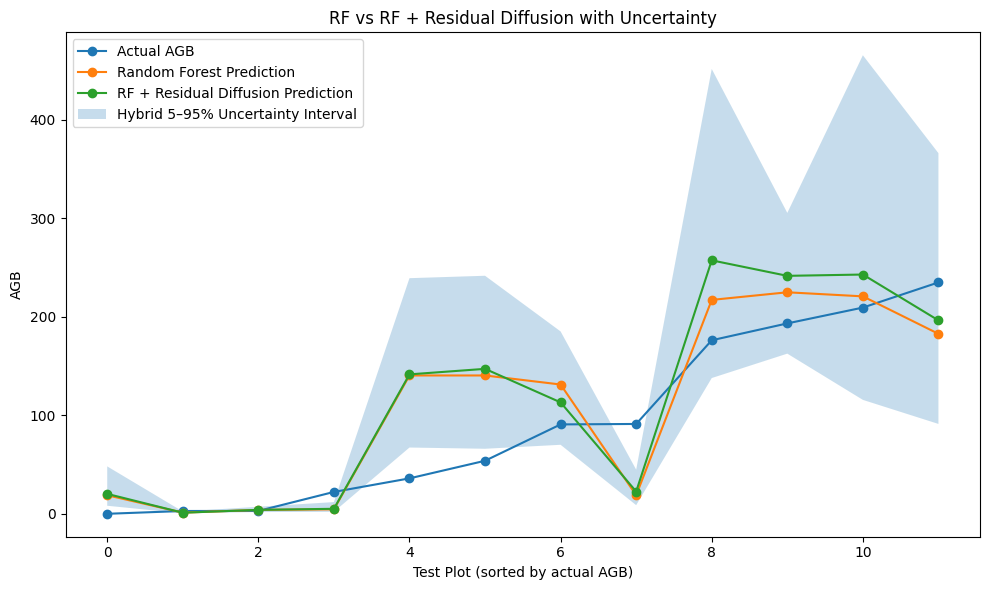

In [29]:
import numpy as np
import matplotlib.pyplot as plt

order = np.argsort(y_true)
actual_sorted = y_true[order]
rf_sorted = np.expm1(rf_test_pred_log)[order]
hybrid_sorted = hybrid_pred[order]
lower_sorted = hybrid_lower[order]
upper_sorted = hybrid_upper[order]

x = np.arange(len(y_true))

plt.figure(figsize=(10, 6))
plt.plot(x, actual_sorted, marker="o", label="Actual AGB")
plt.plot(x, rf_sorted, marker="o", label="Random Forest Prediction")
plt.plot(x, hybrid_sorted, marker="o", label="RF + Residual Diffusion Prediction")
plt.fill_between(
    x,
    lower_sorted,
    upper_sorted,
    alpha=0.25,
    label="Hybrid 5–95% Uncertainty Interval"
)

plt.xlabel("Test Plot (sorted by actual AGB)")
plt.ylabel("AGB")
plt.title("RF vs RF + Residual Diffusion with Uncertainty")
plt.legend()
plt.tight_layout()
plt.show()

The comparison between Random Forest predictions and the hybrid residual diffusion model shows that while the hybrid approach does not significantly improve point prediction accuracy, it provides meaningful uncertainty estimates. The uncertainty bands are narrow for low biomass values and widen substantially for higher biomass levels, reflecting increased model uncertainty. In most cases, the true biomass values fall within the predicted intervals, demonstrating that the model is well-calibrated. This highlights the value of residual diffusion as a tool for uncertainty quantification rather than improving predictive accuracy.